In [5]:
import pandas as pd
import numpy as np
from numpy import transpose as T
import glob
import os
import cartopy
import cartopy.crs as ccrs
import matplotlib
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.lines as mlines
from matplotlib.ticker import MultipleLocator
from matplotlib.gridspec import GridSpec
import matplotlib.cm as cm
import geopandas as gpd
from scipy.optimize import curve_fit
from netCDF4 import Dataset
import scipy
from scipy import stats
from scipy.ndimage import distance_transform_edt
from datetime import datetime,timedelta
from numpy import genfromtxt as gftxt
import regionmask
from pyproj import Transformer
from datetime import datetime,timedelta
import sys
from pathlib import Path

In [6]:
sys.path.append(str(Path.cwd().parents[0]))
from utils.grid_map_functions import(land_masking, defining_grids)

map_projection = ccrs.NorthPolarStereo()

x_grid_edge_25,y_grid_edge_25,new_x_edge_25,new_y_edge_25 = defining_grids(map_projection,[-180, 180, 90, 65],25000,'edge')
x_grid_centre_25,y_grid_centre_25,new_x_centre_25,new_y_centre_25 = defining_grids(map_projection,[-180, 180, 90, 65],25000,'centre')
land_mask_25 = land_masking(new_x_centre_25,new_y_centre_25,map_projection)

transformer = Transformer.from_crs(map_projection, "EPSG:4326", always_xy=True)
lon0, lat0 = transformer.transform(new_x_centre_25.ravel(), new_y_centre_25.ravel())
lon1 = lon0.reshape(new_x_centre_25.shape)
lat1 = lat0.reshape(new_y_centre_25.shape)

from utils.stats_functions import(absdiff,corr,rmsd)

base_dir = ('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Data/')

In [7]:
def add_land_buffer_distance(land_mask, grid_spacing_km, buffer_km):
    """
    Create buffer based on real distance (km)
    """
    # दूरी from land: compute distance from NON-land
    distance = distance_transform_edt(~land_mask) * grid_spacing_km
    
    # mask where within buffer distance
    buffer_mask = distance <= buffer_km
    
    return land_mask | buffer_mask

def ls8_area_masking(lon, lat, shapefile, buffer):
    # Union all geometries
    geom = shapefile.geometry.union_all()

    # Apply buffer if requested
    if buffer != 0:
        geom = geom.buffer(buffer)

    # Prep geometry for fast lookup
    p_geom = prep(geom)

    # Create mask
    mask = np.zeros(lon.shape, dtype=bool)
    for i in range(lon.shape[0]):
        for j in range(lon.shape[1]):
            mask[i, j] = p_geom.contains(Point(lon[i, j], lat[i, j]))

    return mask


colors = [
    'indianred',# 0 clouds
    'lightgrey', # 1 land
    'white',# 2 sea ice
    'orange',# 3 artefacts
    'steelblue', # 4 leads
    'navy'# 5 open water
]

cmap = ListedColormap(colors)
norm = BoundaryNorm(boundaries=np.arange(-0.5, 6.5, 1),ncolors=cmap.N)

land_mask_buffered = add_land_buffer_distance(land_mask_25,grid_spacing_km=25,buffer_km=5)


In [10]:
base_dir = ('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Data/')
map_projection = ccrs.NorthPolarStereo()
PROJ_CRS = "+proj=stere +lat_0=90 +lon_0=0 +datum=WGS84 +units=m +no_defs"
transformer = Transformer.from_crs("EPSG:4326", PROJ_CRS, always_xy=True)

# Reproject the lat lon
test_modis = Dataset(base_dir+'MODIS_LeadFraction/2018_ArcLeads.nc') 
lat = test_modis.variables['lat'][:]
lon = test_modis.variables['lon'][:]

x_src, y_src = transformer.transform(lon.ravel(), lat.ravel())
x_idx = np.digitize(x_src, x_grid_edge_25) - 1
y_idx = np.digitize(y_src, y_grid_edge_25) - 1

inside = ((x_idx >= 0) & (x_idx < new_x_centre_25.shape[1]) &
    (y_idx >= 0) & (y_idx < new_x_centre_25.shape[0]))

x_idx = x_idx[inside]
y_idx = y_idx[inside]

target_flat = y_idx * new_x_centre_25.shape[1] + x_idx
n_cells = new_x_centre_25.size


In [12]:
# Generate a given example of gridding procedure

modis_fp = (f"{base_dir}MODIS_LeadFraction/2018_ArcLeads.nc") 
modis_lf = Dataset(modis_fp)

lat = modis_lf['lat'][:]
lon = modis_lf['lon'][:]
leadmap = modis_lf['leadmap']
time_var = modis_lf['time'][:]
dates = pd.to_datetime(time_var.astype(str), format='%Y%m%d')
target_date = pd.Timestamp('2019-01-01')

idx = np.where(dates == target_date)[0][0]
leadmap_day = modis_lf.variables['leadmap'][idx, :, :]

See Reiser et al. 2020 (https://www.mdpi.com/2072-4292/12/12/1957)
and 
Willmes et al. 2023 (https://tc.copernicus.org/articles/17/3291/2023/)
for steps for generating lead density from input lead maps

In [13]:
r_date = ('20190101')
r_datetime = pd.to_datetime(r_date, format='%Y%m%d')

print(f"Processing: {r_datetime}")

mask = (dates == r_datetime)
idx = np.where(mask)[0]

daily_maps = {}

for t in idx:
    lm = leadmap[t, :, :]

    # Skip very cloudy/high artefact days
    cloud_art = (lm == 0) | (lm == 3)
    cloud_fraction = np.count_nonzero(cloud_art) / lm.size
    if cloud_fraction > 0.5:
        print('Cloud Fraction too high')
        continue

    data = lm.ravel()[inside]
    # Count leads and ice per 25 km cell using bincount
    lead_mask = (data == 4).astype(np.int32)
    ice_mask  = (data == 2).astype(np.int32)

    lead_counts_flat = np.bincount(target_flat, weights=lead_mask, minlength=n_cells)
    ice_counts_flat  = np.bincount(target_flat, weights=ice_mask, minlength=n_cells)

    lead_counts = lead_counts_flat.reshape(new_x_centre_25.shape)
    ice_counts  = ice_counts_flat.reshape(new_x_centre_25.shape)

    denom = lead_counts + ice_counts
    daily_lfa = np.full(new_x_centre_25.shape, np.nan, dtype=float)

    valid = denom > 0
    daily_lfa[valid] = (lead_counts[valid] / denom[valid]) * 100.0

    daily_maps[r_date] = (daily_lfa)


Processing: 2019-01-01 00:00:00


In [14]:
leadmap_month = np.load(f"{base_dir}MODIS_LeadFraction/Monthly_Averages_25km_Grid/"
                        f"20190101_20190131_MODIS_Monthly_Average_LFA.npy")


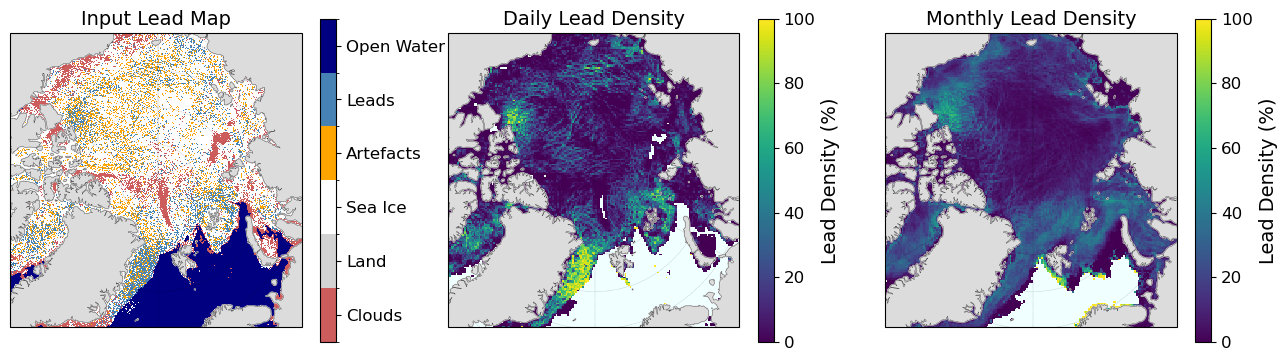

In [16]:
map_projection = ccrs.NorthPolarStereo()

fig,ax = plt.subplots(1, 3,figsize=(16, 7),
    subplot_kw={'projection': ccrs.NorthPolarStereo()})

pcm = ax[0].pcolormesh(lon,lat,leadmap_day,
    cmap=cmap,norm=norm,transform=ccrs.PlateCarree(),shading='nearest',zorder=2)

cbar = plt.colorbar(pcm,
    ax=ax[0],
    shrink=0.6,
    pad=0.05,
    ticks=np.arange(6))
cbar.ax.tick_params(labelsize=12) 

cbar.ax.set_yticklabels(['Clouds',
    'Land',
    'Sea Ice',
    'Artefacts',
    'Leads',
    'Open Water'])

ax[0].set_title('Input Lead Map', fontsize=14)

lf_d = ax[1].pcolormesh(new_x_centre_25,new_y_centre_25, daily_maps['20190101'],
    transform=map_projection,zorder=2)
cbar1 = plt.colorbar(lf_d, ax=ax[1], label='Lead Fraction (%)', shrink=0.6, pad=0.05)
cbar1.ax.tick_params(labelsize=12) 
cbar1.set_label('Lead Density (%)', fontsize=14)
ax[1].set_title('Daily Lead Density', fontsize=14)

lf_m = ax[2].pcolormesh(new_x_centre_25,new_y_centre_25, leadmap_month,
    transform=map_projection,zorder=2)
cbar2 = plt.colorbar(lf_m, ax=ax[2],shrink=0.6, pad=0.05)
cbar2.ax.tick_params(labelsize=12) 
cbar2.set_label('Lead Density (%)', fontsize=14)
ax[2].set_title('Monthly Lead Density', fontsize=14)

for i in range(0,3):
    ax[i].coastlines(linewidth=0.2,zorder=2.5)
    ax[i].gridlines(linewidth=0.3, color='k', alpha=0.5, linestyle=':')
    ax[i].add_feature(cartopy.feature.LAND, color=('gainsboro'), edgecolor='black',zorder=2)
    ax[i].add_feature(cartopy.feature.OCEAN, color=('azure'),edgecolor='black',zorder=0)
    ax[i].set_extent([-180, 180, 90, 70], ccrs.PlateCarree())
    
plt.show()

fig.savefig('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Arctic_Lead_Density_AES/Resubmission_Figures/FigA2.png',dpi=300,bbox_inches="tight")